In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sableenkaur","key":"e7c87c82330a5e87502f3cc427afd644"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp "kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# carDD
!kaggle datasets download -d issamjebnouni/cardd
!unzip -q cardd.zip -d cardd/

Dataset URL: https://www.kaggle.com/datasets/issamjebnouni/cardd
License(s): unknown
100% 2.81G/2.81G [00:41<00:00, 73.3MB/s]



In [ ]:
!ls cardd/

image_info.xlsx  test  test.json  train  train.json  val  val.json


In [ ]:
import os
unzipped_path = '/content/cardd'
# List everything and identify if it's a file or directory
items = os.listdir(unzipped_path)
print("Contents of the folder:")

for item in items:
    full_path = os.path.join(unzipped_path, item)
    if os.path.isdir(full_path):
        print(f"📂 Folder: {item}")
    elif os.path.isfile(full_path):
        print(f"📄 File:   {item}")
    else:
        print(f"Unknown type: {item}")


Contents of the folder:
📄 File:   test.json
📂 Folder: val
📄 File:   train.json
📂 Folder: test
📂 Folder: train
📄 File:   image_info.xlsx
📄 File:   val.json


In [ ]:
import os
train_folder = "cardd/train"
val_folder = "cardd/val"
test_folder = "cardd/test"

print("CarDD dataset:")
print("Train images:", len(os.listdir(train_folder)))
print("Validation images:", len(os.listdir(val_folder)))
print("Test images:", len(os.listdir(test_folder)))

CarDD dataset:
Train images: 2816
Validation images: 810
Test images: 374



Showing from TRAIN set

loading annotations into memory...
Done (t=0.27s)
creating index...
index created!


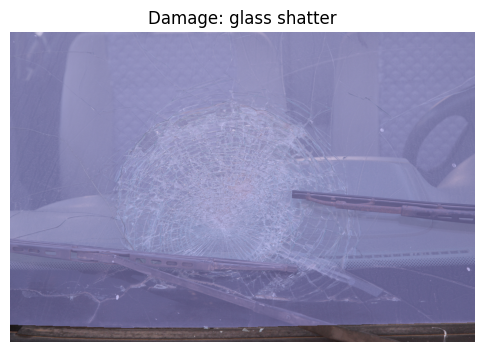

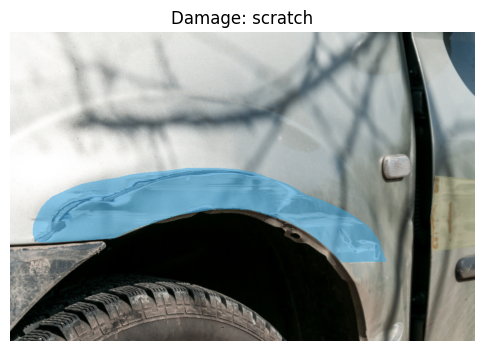


Showing from VAL set

loading annotations into memory...
Done (t=0.09s)
creating index...
index created!


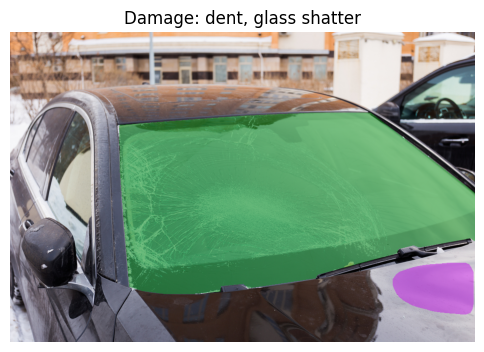

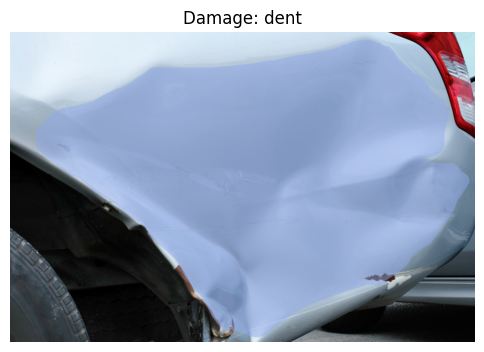


Showing from TEST set

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


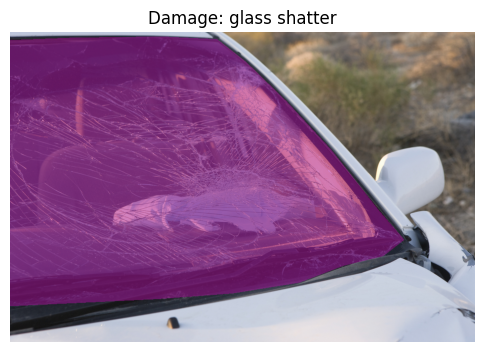

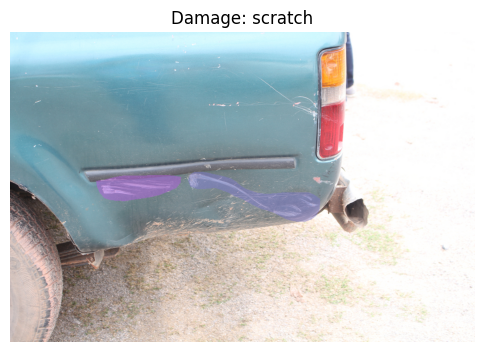

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

# Base path
base_path = "/content/cardd"

# Function to visualize random images
def show_random_images(split_name, num_images=2):

    print(f"\nShowing from {split_name.upper()} set\n")

    images_path = os.path.join(base_path, split_name)
    annotation_path = os.path.join(base_path, f"{split_name}.json")

    coco = COCO(annotation_path)
    img_ids = coco.getImgIds()

    random_ids = random.sample(img_ids, num_images)

    for img_id in random_ids:

        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(images_path, img_info['file_name'])

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        category_names = []

        for ann in anns:
            mask = coco.annToMask(ann)

            # Get category name
            cat_id = ann['category_id']
            cat_name = coco.loadCats(cat_id)[0]['name']
            category_names.append(cat_name)

            # Random color mask
            color = np.random.randint(0, 255, (3,), dtype=np.uint8)
            image[mask == 1] = image[mask == 1] * 0.5 + color * 0.5

        plt.figure(figsize=(6,6))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Damage: {', '.join(set(category_names))}")
        plt.show()


# Show images from all splits
show_random_images("train", 2)
show_random_images("val", 2)
show_random_images("test", 2)


In [ ]:
import json
with open("/content/cardd/train.json") as f:
    data = json.load(f)

# Print one sample
print(list(data.items())[2])


('categories', [{'id': 1, 'name': 'dent', 'supercategory': 'car damages'}, {'id': 2, 'name': 'scratch', 'supercategory': 'car damages'}, {'id': 3, 'name': 'crack', 'supercategory': 'car damages'}, {'id': 4, 'name': 'glass shatter', 'supercategory': 'car damages'}, {'id': 5, 'name': 'lamp broken', 'supercategory': 'car damages'}, {'id': 6, 'name': 'tire flat', 'supercategory': 'car damages'}])


In [ ]:
data['annotations'][101]

{'id': 102,
 'image_id': 63,
 'category_id': 5,
 'segmentation': [[265.87,
   131.76,
   151.54,
   175.79,
   85.87,
   226.01,
   83.55,
   257.68,
   122.18,
   295.54,
   148.45,
   305.58,
   161.58,
   310.99,
   173.94,
   314.85,
   186.3,
   318.71,
   197.89,
   321.03,
   212.57,
   323.35,
   228.02,
   326.44,
   239.61,
   329.53,
   251.19,
   331.07,
   365.53,
   341.12,
   383.3,
   341.89,
   397.2,
   341.89,
   409.56,
   341.89,
   425.79,
   340.34,
   442.01,
   338.03,
   458.23,
   334.94,
   476.0,
   331.07,
   503.04,
   328.76,
   516.17,
   326.44,
   529.3,
   324.89,
   543.21,
   322.58,
   556.34,
   320.26,
   571.79,
   314.85,
   582.61,
   308.67,
   594.2,
   303.26,
   604.24,
   295.54,
   695.4,
   255.36,
   836.0,
   176.57,
   916.34,
   127.12,
   897.03,
   119.4,
   885.44,
   118.63,
   769.56,
   127.12,
   503.04,
   130.99,
   349.3,
   107.81,
   302.95,
   119.4]],
 'area': 124071.0,
 'bbox': [83.55, 107.81, 832.79, 234.08],
 'iscr

In [ ]:
data['categories'][1]

{'id': 2, 'name': 'scratch', 'supercategory': 'car damages'}

In [ ]:
import json
with open("/content/cardd/test.json") as f:
    data_test= json.load(f)

# Print one sample
print(list(data_test.items())[2])


('categories', [{'id': 1, 'name': 'dent', 'supercategory': 'car damages'}, {'id': 2, 'name': 'scratch', 'supercategory': 'car damages'}, {'id': 3, 'name': 'crack', 'supercategory': 'car damages'}, {'id': 4, 'name': 'glass shatter', 'supercategory': 'car damages'}, {'id': 5, 'name': 'lamp broken', 'supercategory': 'car damages'}, {'id': 6, 'name': 'tire flat', 'supercategory': 'car damages'}])


In [ ]:
data_test['annotations'][101]

{'id': 102,
 'image_id': 520,
 'category_id': 1,
 'segmentation': [[154.41,
   579.86,
   141.91,
   587.81,
   133.96,
   594.63,
   126.57,
   602.01,
   120.89,
   609.97,
   114.08,
   619.62,
   110.1,
   628.14,
   108.4,
   638.37,
   114.08,
   645.75,
   123.73,
   648.59,
   133.39,
   650.86,
   143.05,
   652.57,
   152.7,
   653.14,
   164.06,
   653.14,
   174.29,
   653.14,
   181.67,
   648.02,
   186.22,
   626.44,
   190.76,
   617.92,
   194.74,
   609.4,
   198.15,
   599.17,
   200.42,
   590.65,
   202.12,
   580.43,
   202.12,
   569.64,
   202.12,
   560.55,
   193.03,
   556.0,
   183.95,
   557.71,
   175.99,
   563.39,
   169.18,
   569.07]],
 'area': 5695.0,
 'bbox': [108.4, 556.0, 93.72, 97.14],
 'iscrowd': 0,
 'attributes': {'occluded': False}}

In [ ]:
data_test['categories'][1]

{'id': 2, 'name': 'scratch', 'supercategory': 'car damages'}

In [ ]:
with open("cardd/train.json", "r") as f:
    data = json.load(f)

categories = data["categories"]
print("Number of damage categories:", len(categories))
print("Damage Categories:\n")

for cat in categories:
    print(f"ID: {cat['id']} | Name: {cat['name']}")


Number of damage categories: 6
Damage Categories:

ID: 1 | Name: dent
ID: 2 | Name: scratch
ID: 3 | Name: crack
ID: 4 | Name: glass shatter
ID: 5 | Name: lamp broken
ID: 6 | Name: tire flat


In [ ]:
from collections import Counter

category_count = Counter()

for ann in data["annotations"]:
    category_count[ann["category_id"]] += 1

print("Annotation count per category:")
for cat in categories:
    print(f"{cat['name']}: {category_count[cat['id']]}")


Annotation count per category:
dent: 1806
scratch: 2560
crack: 651
glass shatter: 475
lamp broken: 494
tire flat: 225


loading annotations into memory...
Done (t=0.26s)
creating index...
index created!


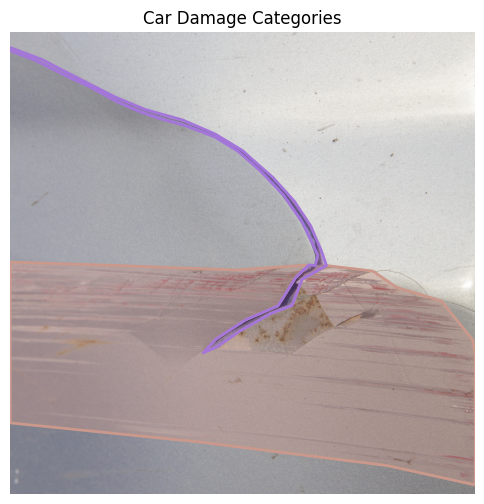

In [ ]:
from pycocotools.coco import COCO
coco = COCO("cardd/train.json")

img_id = random.choice(coco.getImgIds())
img_info = coco.loadImgs(img_id)[0]

img = cv2.imread(f"cardd/train/{img_info['file_name']}")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

ann_ids = coco.getAnnIds(imgIds=img_id)
anns = coco.loadAnns(ann_ids)

plt.figure(figsize=(6,6))
plt.imshow(img)
coco.showAnns(anns)
plt.title("Car Damage Categories")
plt.axis("off")
plt.show()

#Clean Dataset


In [ ]:
!kaggle datasets download -d kshitij192/cars-image-dataset
!unzip -q cars-image-dataset.zip -d /content/

Dataset URL: https://www.kaggle.com/datasets/kshitij192/cars-image-dataset
License(s): GPL-2.0
100% 36.3M/36.3M [00:00<00:00, 106MB/s] 



In [ ]:
!ls "/content/Cars Dataset"

test  train


In [ ]:
import os
train_folder = "/content/Cars Dataset/train"
test_folder = "/content/Cars Dataset/test"

num_train_images = 0
for root, dirs, files in os.walk(train_folder):
    num_train_images += len(files)

num_test_images = 0
for root, dirs, files in os.walk(test_folder):
    num_test_images += len(files)

print(f"Number of images in the training set: {num_train_images}")
print(f"Number of images in the test set: {num_test_images}")

Number of images in the training set: 3352
Number of images in the test set: 813


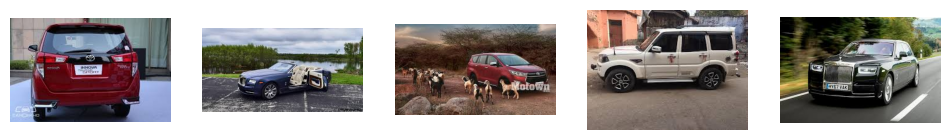

In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

train_folder = "/content/Cars Dataset/train"

# collect all image paths
image_paths = []
for root, dirs, files in os.walk(train_folder):
    for file in files:
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):
            image_paths.append(os.path.join(root, file))

# randomly select 5 images
random_images = random.sample(image_paths, 5)

# display images
plt.figure(figsize=(12, 6))
for i, img_path in enumerate(random_images):
    img = Image.open(img_path)
    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.show()


In [ ]:
import os
import shutil
import json
from PIL import Image

# 1. Define Paths
cardd_base = "/content/cardd"
clean_base_train = "/content/Cars Dataset/train"
clean_base_test = "/content/Cars Dataset/test"

splits = {
    "train": {"src": clean_base_train, "count": 300, "json": "train.json"},
    "val":   {"src": clean_base_test,  "count": 50,  "json": "val.json"},
    "test":  {"src": clean_base_test,  "count": 50,  "json": "test.json"}
}

def update_coco_with_clean(split_name, src_dir, count, json_filename):
    json_path = os.path.join(cardd_base, json_filename)
    img_dest_dir = os.path.join(cardd_base, split_name)

    # Load existing JSON
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Get current max ID to avoid duplicates
    max_img_id = max([img['id'] for img in data['images']]) if data['images'] else 0

    # Get clean images from source (walking through subfolders)
    clean_images = []
    for root, dirs, files in os.walk(src_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                clean_images.append(os.path.join(root, file))

    # Limit to the count we want
    selected_images = clean_images[:count]

    print(f"Adding {len(selected_images)} clean images to {split_name}...")

    for i, src_path in enumerate(selected_images):
        new_filename = f"clean_{i}_{os.path.basename(src_path)}"
        dst_path = os.path.join(img_dest_dir, new_filename)

        # Copy the file
        shutil.copy(src_path, dst_path)

        # Get image dimensions
        with Image.open(dst_path) as img:
            width, height = img.size

        # Add to JSON 'images' list ONLY (leave 'annotations' empty)
        max_img_id += 1
        data['images'].append({
            "id": max_img_id,
            "file_name": new_filename,
            "width": width,
            "height": height
        })

    # Save the updated JSON
    with open(json_path, 'w') as f:
        json.dump(data, f)
    print(f"Successfully updated {json_filename}")

# Execute for all splits
for split, config in splits.items():
    update_coco_with_clean(split, config['src'], config['count'], config['json'])

Adding 300 clean images to train...
Successfully updated train.json
Adding 50 clean images to val...
Successfully updated val.json
Adding 50 clean images to test...
Successfully updated test.json


In [ ]:
import os
train_folder = "cardd/train"
val_folder = "cardd/val"
test_folder = "cardd/test"

print("CarDD dataset:")
print("Train images:", len(os.listdir(train_folder)))
print("Validation images:", len(os.listdir(val_folder)))
print("Test images:", len(os.listdir(test_folder)))

CarDD dataset:
Train images: 3116
Validation images: 860
Test images: 424


In [ ]:
import json
with open("/content/cardd/test.json") as f:
    data = json.load(f)

# Print one sample
print(list(data.items())[2])


('categories', [{'id': 1, 'name': 'dent', 'supercategory': 'car damages'}, {'id': 2, 'name': 'scratch', 'supercategory': 'car damages'}, {'id': 3, 'name': 'crack', 'supercategory': 'car damages'}, {'id': 4, 'name': 'glass shatter', 'supercategory': 'car damages'}, {'id': 5, 'name': 'lamp broken', 'supercategory': 'car damages'}, {'id': 6, 'name': 'tire flat', 'supercategory': 'car damages'}])


In [ ]:
with open("cardd/train.json", "r") as f:
    data = json.load(f)

categories = data["categories"]
print("Number of damage categories:", len(categories))
print("Damage Categories:\n")

for cat in categories:
    print(f"ID: {cat['id']} | Name: {cat['name']}")


Number of damage categories: 6
Damage Categories:

ID: 1 | Name: dent
ID: 2 | Name: scratch
ID: 3 | Name: crack
ID: 4 | Name: glass shatter
ID: 5 | Name: lamp broken
ID: 6 | Name: tire flat


In [ ]:
from collections import Counter

category_count = Counter()

for ann in data["annotations"]:
    category_count[ann["category_id"]] += 1

print("Annotation count per category:")
for cat in categories:
    print(f"{cat['name']}: {category_count[cat['id']]}")


Annotation count per category:
dent: 1806
scratch: 2560
crack: 651
glass shatter: 475
lamp broken: 494
tire flat: 225


In [ ]:
from collections import Counter
import json

def count_annotations(json_path):
    with open(json_path) as f:
        data = json.load(f)

    category_count = Counter()

    for ann in data["annotations"]:
        category_count[ann["category_id"]] += 1

    print(f"\n📊 {json_path} annotation count:")
    for cat in data["categories"]:
        print(f"{cat['name']}: {category_count[cat['id']]}")

# Run for each split
count_annotations("cardd/train.json")
count_annotations("cardd/val.json")
count_annotations("cardd/test.json")


📊 cardd/train.json annotation count:
dent: 1806
scratch: 2560
crack: 651
glass shatter: 475
lamp broken: 494
tire flat: 225

📊 cardd/val.json annotation count:
dent: 501
scratch: 728
crack: 177
glass shatter: 135
lamp broken: 141
tire flat: 62

📊 cardd/test.json annotation count:
dent: 236
scratch: 307
crack: 70
glass shatter: 71
lamp broken: 69
tire flat: 32



Showing from TRAIN set

loading annotations into memory...
Done (t=0.14s)
creating index...
index created!


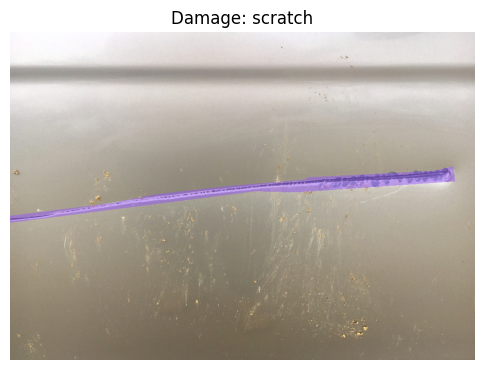

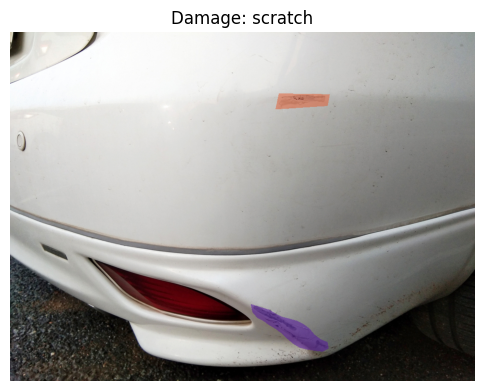


Showing from VAL set

loading annotations into memory...
Done (t=0.06s)
creating index...
index created!


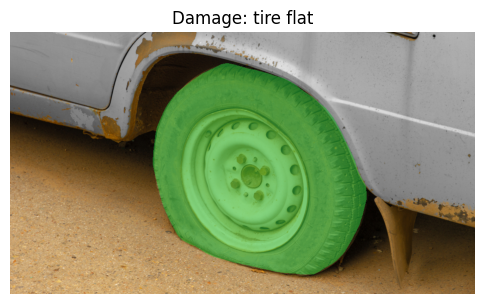

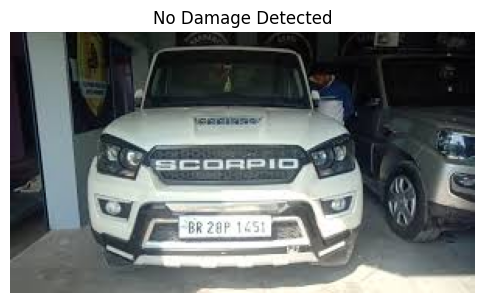


Showing from TEST set

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!


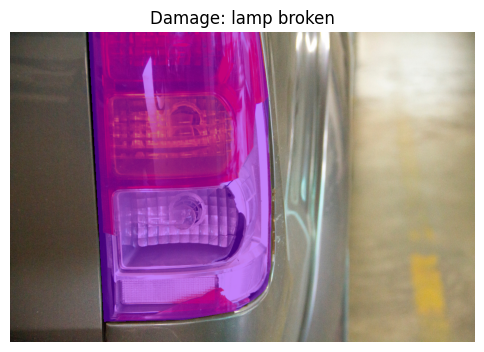

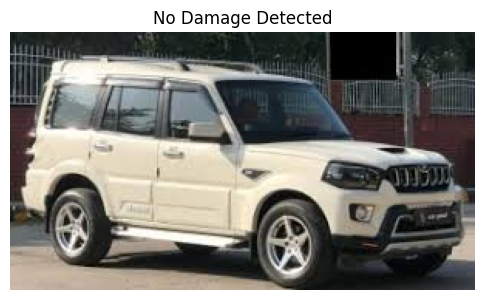

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

# Base dataset path
base_path = "/content/cardd"

# Function to visualize random images
def show_random_images(split_name, num_images=2):

    print(f"\nShowing from {split_name.upper()} set\n")

    images_path = os.path.join(base_path, split_name)
    annotation_path = os.path.join(base_path, f"{split_name}.json")

    coco = COCO(annotation_path)
    img_ids = coco.getImgIds()

    # If dataset has fewer images than requested
    num_images = min(num_images, len(img_ids))
    random_ids = random.sample(img_ids, num_images)

    for img_id in random_ids:

        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(images_path, img_info['file_name'])

        image = cv2.imread(img_path)

        if image is None:
            print(f"Could not read image: {img_path}")
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        category_names = []

        # If there are annotations, draw masks
        for ann in anns:
            mask = coco.annToMask(ann)

            # Get category name
            cat_id = ann['category_id']
            cat_name = coco.loadCats(cat_id)[0]['name']
            category_names.append(cat_name)

            # Random color overlay
            color = np.random.randint(0, 255, (3,), dtype=np.uint8)
            image[mask == 1] = image[mask == 1] * 0.5 + color * 0.5

        # Handle No Damage case
        if len(category_names) == 0:
            title_text = "No Damage Detected"
        else:
            title_text = "Damage: " + ", ".join(set(category_names))

        plt.figure(figsize=(6,6))
        plt.imshow(image)
        plt.axis("off")
        plt.title(title_text)
        plt.show()


# Show images from all splits
show_random_images("train", 2)
show_random_images("val", 2)
show_random_images("test", 2)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
